# <font color="#CE4A06">Support Vector Machine (SVM) With 'Iris' Dataset</font>

Again, we'll use the iris dataset for this lesson.

The 'iris' dataset contains 3 classes of 50 instances each, where each class refers to a type of iris plant.

**Attribute Information:**  
1. sepal length in cm
2. sepal width in cm
3. petal length in cm
4. petal width in cm
5. Class<sup>*</sup> (iris species):
   - Iris Setosa
   - Iris Versicolour
   - Iris Virginica  

<sup>*</sup>Label variable

&nbsp;  
#### <font color="#1f7d02">*Read Dataset*</font>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
df_iris = pd.read_csv("https://raw.githubusercontent.com/ThammakornS/ProgStat/main/dataset/iris.csv")
df_iris.head()

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


&nbsp;  
#### <font color="#1f7d02">*Adjust Data Type*</font>

In [3]:
df_iris = df_iris.astype({
    'Class': 'category',
})
df_iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal-length  150 non-null    float64 
 1   sepal-width   150 non-null    float64 
 2   petal-length  150 non-null    float64 
 3   petal-width   150 non-null    float64 
 4   Class         150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


\
*For ease of visualizations, we will use **only petal-length and sepal-length** data.*

In [4]:
df_iris = df_iris.filter(['petal-length', 'sepal-length', 'Class'])

<Axes: xlabel='petal-length', ylabel='sepal-length'>

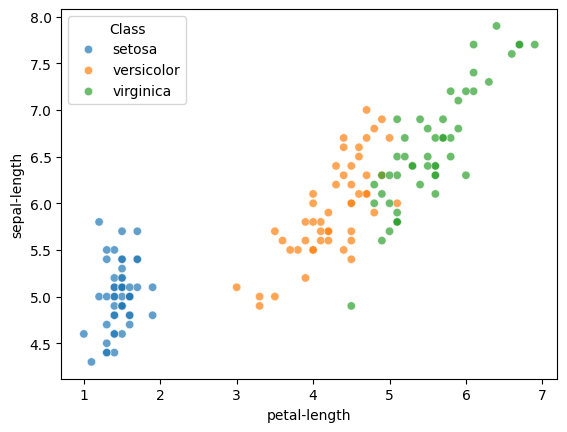

In [5]:
sns.scatterplot(data=df_iris,
                x='petal-length',
                y='sepal-length',
                hue='Class',
                alpha=.7)

&nbsp;  
#### <font color="#1f7d02">*Separate Dataset into Feature and Label Data*</font>

X: features/variable data  
y: outcome/label data

In [6]:
X = df_iris.loc[:,~(df_iris.columns=='Class')]
X

,petal-length,sepal-length
0,1.4,5.1
1,1.4,4.9
2,1.3,4.7
3,1.5,4.6
4,1.4,5.0
...,...,...
145,5.2,6.7
146,5.0,6.3
147,5.2,6.5
148,5.4,6.2


In [7]:
y = df_iris['Class']
y.value_counts()

,count
Class,
setosa,50
versicolor,50
virginica,50


&nbsp;  
#### <font color="#1f7d02">*Train Test Split*</font>

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1234)

In [9]:
X_train.shape

(105, 2)

In [10]:
X_test.shape

(45, 2)

In [11]:
y_train.value_counts()

,count
Class,
virginica,38
setosa,34
versicolor,33


In [12]:
y_test.value_counts()

,count
Class,
versicolor,17
setosa,16
virginica,12


\
Reset all indices to start from 0 to avoid further confusion.

In [12]:
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

&nbsp;  
#### <font color="#1f7d02">*Feature Data Scaling*</font>

\
Check data scale in each column:

In [13]:
df_iris.std(numeric_only=True)

,0
petal-length,1.764420
sepal-length,0.828066


\
Performing feature data scaling:

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

\
Scale training set

In [15]:
X_train_sc = scaler.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)

In [18]:
X_train_sc.std(numeric_only=True)

,0
petal-length,1.004796
sepal-length,1.004796


&nbsp;  
Scale test set

In [16]:
X_test_sc = scaler.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

In [20]:
X_test_sc.std(numeric_only=True)

,0
petal-length,1.032011
sepal-length,1.087273


&nbsp;  
#### <font color="#166e20">*Setup SVM Models*</font>

\
<font color="#275bb0">**Linear kernel**</font>

In [17]:
from sklearn import svm
svm_l = svm.SVC(kernel='linear',
                C=1, # C is Regularization parameter, default=1.0
                probability=True) # Calculate probability, this option is False by default. However, we need probability for calculating multi-class auc
# SVC stands for support vector classifier
# If you want to create regressor, use .SVR instead of .SVC

\
<font color="#275bb0">**Radial basis function (rbf) kernel**</font>

In [18]:
svm_rbf = svm.SVC(kernel='rbf',
                  C=1,
                  gamma='scale',
                  probability=True)
# gamma is a coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’ kernels.
# if gamma='scale' (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,
# if ‘auto’, uses 1 / n_features.

For more information see: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

&nbsp;  
#### <font color="#166e20">*Setup Cross-Validation For Model Evaluation & Parameter Tuning*</font>

For this lesson, we will use stratified K-fold cross-validation.

In [19]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

&nbsp;  
#### <font color="#166e20">*Evaluate Models Training Performance*</font>

\
<font color="#275bb0">**Linear kernel**</font>

In [20]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(estimator=svm_l, # svm with linear kernel
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)

\
Display confusion matrix:

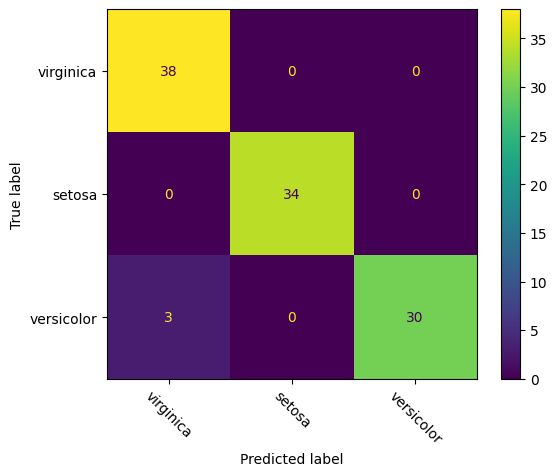

In [21]:
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=['virginica','setosa','versicolor'])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=['virginica','setosa','versicolor']).plot(xticks_rotation=-45)

\
Get precision, recall, and f1 scores:

In [22]:
print(metrics.classification_report(y_train, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        34
  versicolor       1.00      0.91      0.95        33
   virginica       0.93      1.00      0.96        38

    accuracy                           0.97       105
   macro avg       0.98      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105



In [23]:
acc = metrics.accuracy_score(y_train, y_pred)
precision = metrics.precision_score(y_train, y_pred, average='weighted')
recall = metrics.recall_score(y_train, y_pred, average='weighted')
f1 = metrics.f1_score(y_train, y_pred, average='weighted')

print(f"acc={acc:.2f}")
print(f"precision={precision:.2f}")
print(f"recall={recall:.2f}")
print(f"f1={f1:.2f}")

acc=0.97
precision=0.97
recall=0.97
f1=0.97


\
<font color="#275bb0">**Get class prediction probabilities (for multi-class AUC calculation)**</font>

\
The label data has 3 classes: 'virginica','setosa', and 'versicolor'.  
To calculate multi-class auc, predicted probabilities are required.

In [24]:
y_pred_proba = cross_val_predict(estimator=svm_l,
                                 method='predict_proba', # The default is 'predict' which not calculate probability
                                 X=X_train_sc,
                                 y=y_train,
                                 cv=skf)

In [25]:
y_pred_proba[0:4]

array([[0.936412  , 0.04487859, 0.01870941],
       [0.01631563, 0.14740811, 0.83627625],
       [0.01747343, 0.24305962, 0.73946694],
       [0.00697657, 0.01754202, 0.97548141]])

Result probabilities are in the form of an numpy array with 3 columns corresponding to 3 classes.  
However, we don't know which class belongs to which column.

\
To know which class belongs to which column, compare y_pred_proba (probabilities) with y_pred (category)  
Let's see the first 10 rows of y_pred_proba:

In [26]:
y_pred_proba[0:9]

array([[9.36411999e-01, 4.48785868e-02, 1.87094139e-02],
       [1.63156323e-02, 1.47408113e-01, 8.36276254e-01],
       [1.74734337e-02, 2.43059625e-01, 7.39466942e-01],
       [6.97656655e-03, 1.75420230e-02, 9.75481410e-01],
       [1.06486932e-02, 3.46506399e-02, 9.54700667e-01],
       [9.49393067e-01, 3.49415316e-02, 1.56654013e-02],
       [2.00303761e-02, 1.77964616e-01, 8.02005008e-01],
       [2.73896442e-03, 6.98997422e-04, 9.96562038e-01],
       [1.63027408e-02, 9.54745339e-01, 2.89519202e-02]])

\
Then compare with the first 10 values of y_pred:

In [27]:
y_pred[0:9]

array(['setosa', 'virginica', 'virginica', 'virginica', 'virginica',
       'setosa', 'virginica', 'virginica', 'versicolor'], dtype=object)

So, the 1st column is 'setosa', 2nd is 'versicolor', and 3rd is 'virginica'

\
For ease of further usages, we will convert y_pred_proba to dataframe and assign name for each column:

In [28]:
y_pred_proba = pd.DataFrame(y_pred_proba, columns=['setosa','versicolor','virginica'])
y_pred_proba

,setosa,versicolor,virginica
0,0.936412,0.044879,0.018709
1,0.016316,0.147408,0.836276
2,0.017473,0.243060,0.739467
3,0.006977,0.017542,0.975481
4,0.010649,0.034651,0.954701
...,...,...,...
100,0.007744,0.004400,0.987856
101,0.013070,0.029790,0.957140
102,0.029997,0.955481,0.014522
103,0.954256,0.027778,0.017966


&nbsp;  
<font color="#275bb0">**Calculate multi-class auc**</font>

AUC is the area under the curve of plot between fpr(false positive rate) and tpr(true positive rate). Both values can be calculated if label data has binary class.  
For multi-class label (more than 2 classes), AUC can be estimated using 2 approaches:    

***ovr*** stands for One-vs-Rest. Computes the AUC of each class against the rest. This treats the multiclass case in the same way as the multilabel case. Sensitive to class imbalance even when average == 'macro', because class imbalance affects the composition of each of the ‘rest’ groupings.

***ovo*** Stands for One-vs-One. Computes the average AUC of all possible pairwise combinations of classes. Insensitive to class imbalance when average == 'macro'.

In our case,  
ovr = average of   
    - setosa vs. rest(virginica & versicolor)  
    - virginica vs. rest(setosa & versicolor)  
    - versicolor vs. rest(setosa & virginica)  
  
ovo = average of  
    - setosa vs. virginica  
    - setosa vs. versicolor  
    - virginica vs. versicolor  

&nbsp;  
*Options for 'average' argument:*

None: the scores for each class are returned.  
'macro': Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.  
'weighted': Calculate metrics for each label, and find their average, weighted by support (the number of true instances for each label).  

In [29]:
auc_ovo = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovo', average='weighted')
auc_ovo

0.9956788137902688

In [35]:
auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')
auc_ovr

0.9956605418768288

In [34]:
auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average=None)
auc_ovr

array([1.        , 0.99326599, 0.99371563])

&nbsp;  
Plot multi-class ROC AUC curve (ovr, average=None):

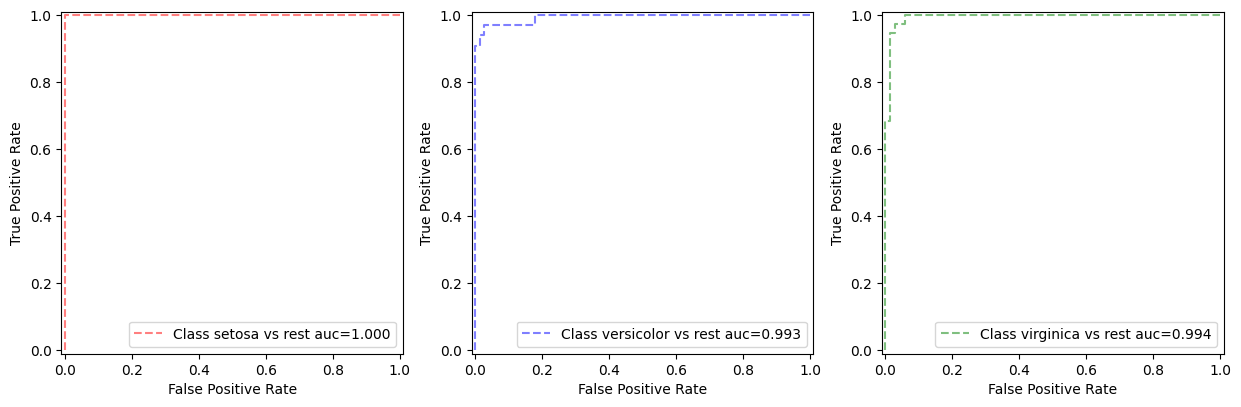

In [37]:
fpr = {}
tpr = {}
thresh ={}

classes = ['setosa','versicolor','virginica']

# get fpr, tpr values
for c in classes:
    fpr[c], tpr[c], thresh[c] = metrics.roc_curve(y_train, y_pred_proba[c], pos_label=c)


# plot
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# setosa vs rest
roc_auc = metrics.auc(fpr['setosa'], tpr['setosa'])
display = metrics.RocCurveDisplay(fpr=fpr['setosa'], tpr=tpr['setosa'])
display.plot(ax=ax[0], linestyle='--',color='r', alpha=0.5, label=f'Class setosa vs rest auc={roc_auc:.3f}')

# versicolor vs rest
roc_auc = metrics.auc(fpr['versicolor'], tpr['versicolor'])
display = metrics.RocCurveDisplay(fpr=fpr['versicolor'], tpr=tpr['versicolor'])
display.plot(ax=ax[1], linestyle='--',color='b', alpha=0.5, label=f'Class versicolor vs rest auc={roc_auc:.3f}')

# virginica vs rest
roc_auc = metrics.auc(fpr['virginica'], tpr['virginica'])
display = metrics.RocCurveDisplay(fpr=fpr['virginica'], tpr=tpr['virginica'])
display.plot(ax=ax[2], linestyle='--',color='g', alpha=0.5, label=f'Class virginica vs rest auc={roc_auc:.3f}')

&nbsp;  
<font color="#275bb0">**Radial basis function (rbf) kernel**</font>

In [38]:
y_pred = cross_val_predict(estimator=svm_rbf, # svm with radial basis function kernel
                           X=X_train_sc,
                           y=y_train,
                           cv=skf)

&nbsp;  
Display confusion matrix:

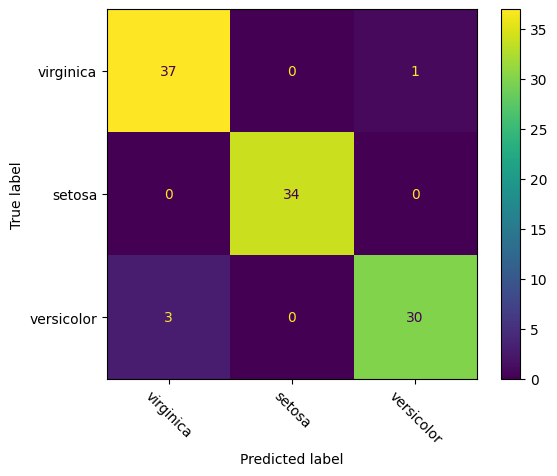

In [39]:
conf_mat = metrics.confusion_matrix(y_train, y_pred, labels=['virginica','setosa','versicolor'])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=['virginica','setosa','versicolor']).plot(xticks_rotation=-45)

&nbsp;  
Get precision, recall, and f1 scores:

In [40]:
print(metrics.classification_report(y_train, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        34
  versicolor       0.97      0.91      0.94        33
   virginica       0.93      0.97      0.95        38

    accuracy                           0.96       105
   macro avg       0.96      0.96      0.96       105
weighted avg       0.96      0.96      0.96       105



In [41]:
acc = metrics.accuracy_score(y_train, y_pred)
precision = metrics.precision_score(y_train, y_pred, average='weighted')
recall = metrics.recall_score(y_train, y_pred, average='weighted')
f1 = metrics.f1_score(y_train, y_pred, average='weighted')

print(f"acc={acc:.2f}")
print(f"precision={precision:.2f}")
print(f"recall={recall:.2f}")
print(f"f1={f1:.2f}")

acc=0.96
precision=0.96
recall=0.96
f1=0.96


\
Get class prediction probabilities (for multi-class AUC calculation):

In [42]:
y_pred_proba = cross_val_predict(estimator=svm_l,
                                 method='predict_proba', # The default is 'predict' which not calculate probability
                                 X=X_train_sc,
                                 y=y_train,
                                 cv=skf)

In [43]:
y_pred_proba[0:9]

array([[9.41164983e-01, 3.99462745e-02, 1.88887425e-02],
       [1.62808371e-02, 1.52129935e-01, 8.31589228e-01],
       [1.88795228e-02, 2.07772662e-01, 7.73347815e-01],
       [7.20147483e-03, 1.46899108e-02, 9.78108614e-01],
       [1.09935793e-02, 2.89917787e-02, 9.60014642e-01],
       [9.45104287e-01, 4.00472181e-02, 1.48484951e-02],
       [1.90132630e-02, 2.27125167e-01, 7.53861570e-01],
       [2.84105987e-03, 9.33959656e-04, 9.96224980e-01],
       [1.47967537e-02, 9.56647706e-01, 2.85555407e-02]])

In [44]:
y_pred[0:9]

array(['setosa', 'virginica', 'virginica', 'virginica', 'virginica',
       'setosa', 'virginica', 'virginica', 'versicolor'], dtype=object)

\
For ease of further usages, we will convert y_pred_proba to dataframe and assign name for each column:

In [45]:
y_pred_proba = pd.DataFrame(y_pred_proba, columns=['setosa','versicolor','virginica'])
y_pred_proba

,setosa,versicolor,virginica
0,0.941165,0.039946,0.018889
1,0.016281,0.152130,0.831589
2,0.018880,0.207773,0.773348
3,0.007201,0.014690,0.978109
4,0.010994,0.028992,0.960015
...,...,...,...
100,0.007812,0.009929,0.982259
101,0.011601,0.034476,0.953923
102,0.028781,0.955364,0.015855
103,0.951088,0.031803,0.017109


\
Calculate multi-class auc:

In [46]:
auc_ovo = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovo', average='weighted')
auc_ovo

0.9958209918736234

In [47]:
auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')
auc_ovr

0.9958008336837872

\
Plot multi-class ROC AUC curve:

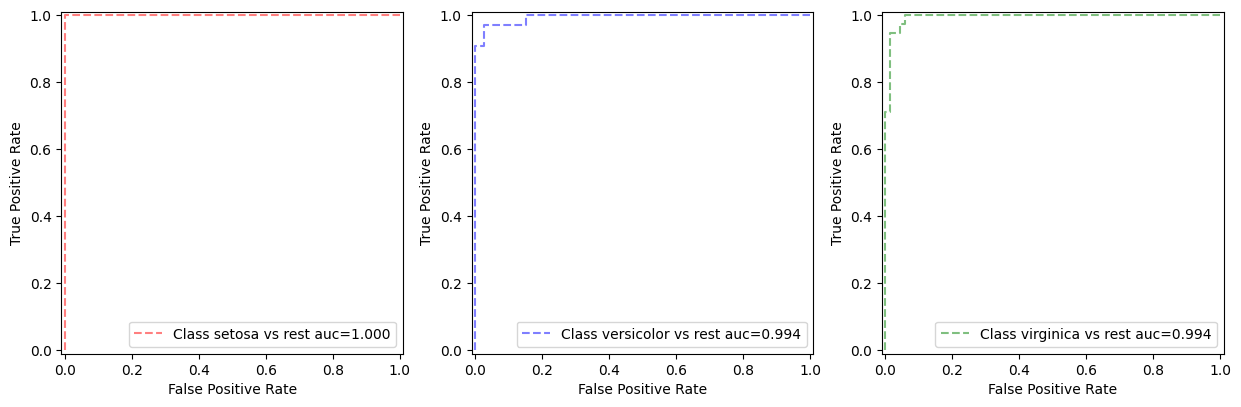

In [48]:
fpr = {}
tpr = {}
thresh ={}

classes = ['setosa','versicolor','virginica']

# get fpr, tpr values
for c in classes:
    fpr[c], tpr[c], thresh[c] = metrics.roc_curve(y_train, y_pred_proba[c], pos_label=c)


# plot
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# setosa vs rest
roc_auc = metrics.auc(fpr['setosa'], tpr['setosa'])
display = metrics.RocCurveDisplay(fpr=fpr['setosa'], tpr=tpr['setosa'])
display.plot(ax=ax[0], linestyle='--',color='r', alpha=0.5, label=f'Class setosa vs rest auc={roc_auc:.3f}')

# versicolor vs rest
roc_auc = metrics.auc(fpr['versicolor'], tpr['versicolor'])
display = metrics.RocCurveDisplay(fpr=fpr['versicolor'], tpr=tpr['versicolor'])
display.plot(ax=ax[1], linestyle='--',color='b', alpha=0.5, label=f'Class versicolor vs rest auc={roc_auc:.3f}')

# virginica vs rest
roc_auc = metrics.auc(fpr['virginica'], tpr['virginica'])
display = metrics.RocCurveDisplay(fpr=fpr['virginica'], tpr=tpr['virginica'])
display.plot(ax=ax[2], linestyle='--',color='g', alpha=0.5, label=f'Class virginica vs rest auc={roc_auc:.3f}')

&nbsp;  
#### <font color="#166e20">*Parameter Tuning Using K-Fold Cross-Validation*</font>

\
<font color="#275bb0">**Linear kernel**</font>

&nbsp;  
Set range of 'C' (regularization parameter) to be tested:

In [49]:
cs = [c for c in range(1,101) if c%10==0 or c==1]
cs

[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

&nbsp;  
Configure cv:

In [50]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

&nbsp;  
Perform cv for each 'C':

In [52]:
perf = {}
perf['C'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc_ovr'] = []
perf['matthew'] = [] #see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html#sklearn.metrics.matthews_corrcoef

for c in cs:
    model_svm = svm.SVC(kernel='linear',
                        C=c,
                        probability=True,
                        random_state=1234) # Controls the pseudo random number generation for shuffling the data for probability estimates.

    # predict class
    y_pred = cross_val_predict(estimator=model_svm,
                               X=X_train_sc,
                               y=y_train,
                               cv=skf)
    acc = metrics.accuracy_score(y_train, y_pred)
    precision = metrics.precision_score(y_train, y_pred, average='weighted')
    recall = metrics.recall_score(y_train, y_pred, average='weighted')
    f1 = metrics.f1_score(y_train, y_pred, average='weighted')
    matw = metrics.matthews_corrcoef(y_train, y_pred)

    # predict probabilities
    y_pred_proba = cross_val_predict(estimator=model_svm,
                                     method='predict_proba', # The default is 'predict' which not calculate probability
                                     X=X_train_sc,
                                     y=y_train,
                                     cv=skf)
    y_pred_proba = pd.DataFrame(y_pred_proba, columns=['setosa','versicolor','virginica'])
    auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')

    perf['C'].append(c)
    perf['acc'].append(acc)
    perf['precision'].append(precision)
    perf['recall'].append(recall)
    perf['f1'].append(f1)
    perf['auc_ovr'].append(auc_ovr)
    perf['matthew'].append(matw)

perf = pd.DataFrame(perf)
perf.sort_values(by=['f1', 'matthew', 'auc_ovr'], ascending=[False, False, False]).head()

,C,acc,precision,recall,f1,auc_ovr,matthew
2,20,0.971429,0.971619,0.971429,0.971394,0.995389,0.957163
0,1,0.971429,0.973519,0.971429,0.971291,0.996072,0.958156
1,10,0.961905,0.961905,0.961905,0.961905,0.995651,0.942748
8,80,0.952381,0.952518,0.952381,0.952324,0.996203,0.928513
3,30,0.952381,0.952518,0.952381,0.952324,0.995932,0.928513


\
Plot performance scores for each 'C':

In [53]:
df_forPlot = pd.melt(perf,
                     value_vars = ['acc', 'precision', 'recall', 'f1', 'auc_ovr', 'matthew'],
                     id_vars = ['C'],
                     var_name = 'Metric',
                     value_name = 'Score')

Text(0.5, 1.0, '5-fold cv performance scores at different C')

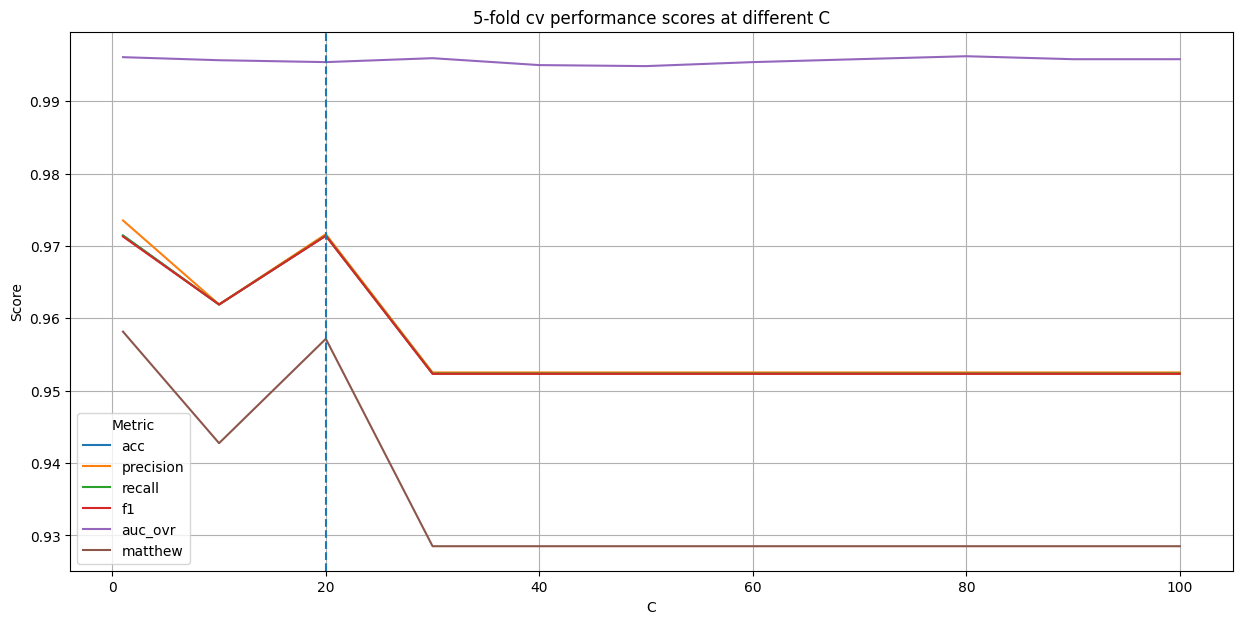

In [54]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.lineplot(data = df_forPlot,
             x = 'C',
             y = 'Score',
             hue = 'Metric',
             ax=ax)
plt.grid()
plt.axvline(x=20, ls="--")
plt.title('5-fold cv performance scores at different C')

\
If we focus on f1, then we select C=20

\
<font color="#275bb0">**Radial basis kernel**</font>

\
Set range of 'C' and 'gamma' to be tested:

In [55]:
cs = [c for c in range(1,101) if c%10==0 or c==1]
cs

[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

For gamma, we will also keep the default value 1 / (n_features * X.var())

In [56]:
default_gamma = 1/(2*X_train_sc.values.flatten().var())
default_gamma

0.5000000000000001

In [57]:
gammas = np.linspace(0.1, 1, 4)
gammas = np.append(gammas, default_gamma)
gammas

array([0.1, 0.4, 0.7, 1. , 0.5])

\
Configure cv:

In [58]:
skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=1234)

\
Perform cv for each 'C':

In [60]:
perf = {}
perf['C'] = []
perf['gamma'] = []
perf['acc'] = []
perf['precision'] = []
perf['recall'] = []
perf['f1'] = []
perf['auc_ovr'] = []
perf['matthew'] = [] #see https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html#sklearn.metrics.matthews_corrcoef

for c in cs:
    for g in gammas:
        model_svm = svm.SVC(kernel='rbf',
                            C=c,
                            gamma=g,
                            probability=True,
                            random_state=1234) # Controls the pseudo random number generation for shuffling the data for probability estimates.

        # predict class
        y_pred = cross_val_predict(estimator=model_svm,
                                   X=X_train_sc,
                                   y=y_train,
                                   cv=skf)
        acc = metrics.accuracy_score(y_train, y_pred)
        precision = metrics.precision_score(y_train, y_pred, average='weighted')
        recall = metrics.recall_score(y_train, y_pred, average='weighted')
        f1 = metrics.f1_score(y_train, y_pred, average='weighted')
        matw = metrics.matthews_corrcoef(y_train, y_pred)

        # predict probabilities
        y_pred_proba = cross_val_predict(estimator=model_svm,
                                         method='predict_proba', # The default is 'predict' which not calculate probability
                                         X=X_train_sc,
                                         y=y_train,
                                         cv=skf)
        y_pred_proba = pd.DataFrame(y_pred_proba, columns=['setosa','versicolor','virginica'])
        auc_ovr = metrics.roc_auc_score(y_train, y_pred_proba, multi_class='ovr', average='macro')

        perf['C'].append(c)
        perf['gamma'].append(g)
        perf['acc'].append(acc)
        perf['precision'].append(precision)
        perf['recall'].append(recall)
        perf['f1'].append(f1)
        perf['auc_ovr'].append(auc_ovr)
        perf['matthew'].append(matw)

perf = pd.DataFrame(perf)
perf.sort_values(by=['f1', 'matthew', 'auc_ovr'], ascending=[False, False, False]).head()

,C,gamma,acc,precision,recall,f1,auc_ovr,matthew
1,1,0.4,0.961905,0.961905,0.961905,0.961905,0.992668,0.942748
50,100,0.1,0.961905,0.961905,0.961905,0.961905,0.992266,0.942748
45,90,0.1,0.961905,0.961905,0.961905,0.961905,0.991845,0.942748
35,70,0.1,0.961905,0.961905,0.961905,0.961905,0.991723,0.942748
40,80,0.1,0.961905,0.961905,0.961905,0.961905,0.991443,0.942748


\
If we focus on f1 > MCC > auc_ovr , then we select C=1 and gamma=0.4.

&nbsp;  
#### <font color="#166e20">*Use SVM models with selected parameters to predict test set*</font>

\
<font color="#275bb0">**Linear kernel**</font>

\
Create SVM model using C=20 and fit on train data:

In [61]:
svm_l = svm.SVC(kernel='linear',
                C=20,
                probability=True)
svm_l.fit(X=X_train_sc, y=y_train)

SVC(C=20, kernel='linear', probability=True)

\
Use above SVM model to predict test set (both class and probabilities):

In [62]:
y_pred_test = svm_l.predict(X_test_sc)
y_pred_proba = svm_l.predict_proba(X_test_sc)

\
Display confusion matrix:

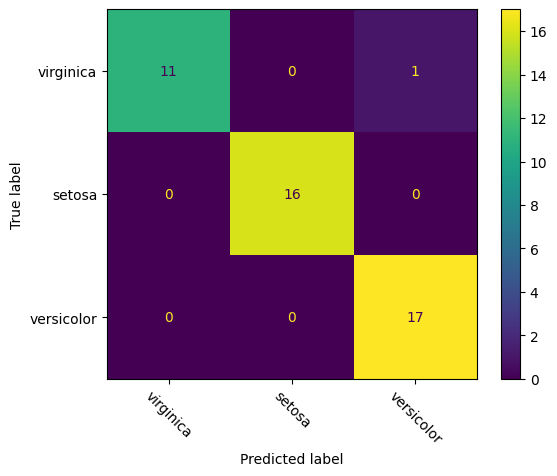

In [63]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=['virginica','setosa','versicolor'])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=['virginica','setosa','versicolor']).plot(xticks_rotation=-45)

&nbsp;  
Evaluate model performance scores based on test set:

In [64]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test, average='weighted')
recall = metrics.recall_score(y_test, y_pred_test, average='weighted')
f1 = metrics.f1_score(y_test, y_pred_test, average='weighted')
matw = metrics.matthews_corrcoef(y_test, y_pred_test)
auc_ovr = metrics.roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc_ovr: {auc_ovr:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.98
precision: 0.98
recall: 0.98
f1: 0.98
auc_ovr: 1.00
Matthew's corr coef: 0.97



\
**Visualize Model Predictions**  
Similar to KNN lesson, we will create simulate test set for visualization.

In [65]:
X_simu = {}
X_simu['petal-length'] = []
X_simu['sepal-length'] = []

#simulated petal-length
max_petl = max(max(X_train_sc['petal-length']), max(X_test_sc['petal-length']))
min_petl = min(min(X_train_sc['petal-length']), min(X_test_sc['petal-length']))
petl = np.linspace(min_petl, max_petl, 100)

#simulated sepal-length
max_sepl = max(max(X_train_sc['sepal-length']), max(X_test_sc['sepal-length']))
min_sepl = min(min(X_train_sc['sepal-length']), min(X_test_sc['sepal-length']))
sepl = np.linspace(min_sepl, max_sepl, 100)

for p in petl:
    for s in sepl:
        X_simu['petal-length'].append(p)
        X_simu['sepal-length'].append(s)

X_simu = pd.DataFrame(X_simu)
X_simu

,petal-length,sepal-length
0,-1.613371,-1.936124
1,-1.613371,-1.891021
2,-1.613371,-1.845917
3,-1.613371,-1.800814
4,-1.613371,-1.755710
...,...,...
9995,1.766688,2.348715
9996,1.766688,2.393818
9997,1.766688,2.438922
9998,1.766688,2.484025


\
Perform prediction on a simulated test set:

In [66]:
y_pred_simu = svm_l.predict(X_simu)

\
Visualize model prediction:

Text(0.5, 1.0, 'SVM linear kernel C=20')

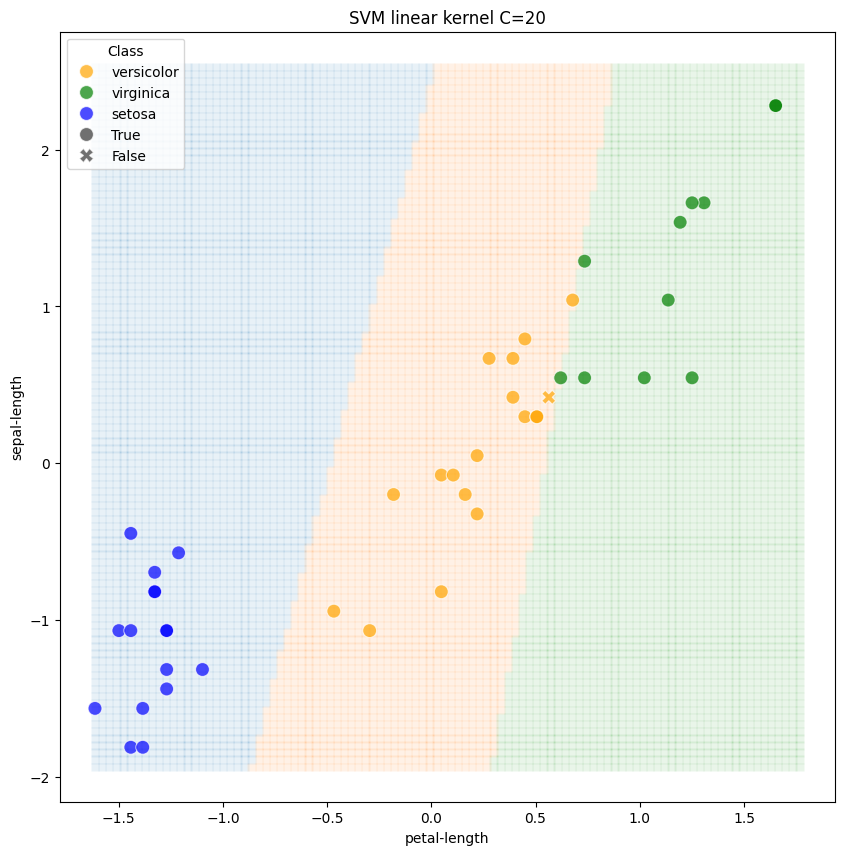

In [67]:
fig, ax = plt.subplots(figsize=(10, 10))

# Simulate data for prediction boundary
sns.scatterplot(data=X_simu,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_simu,
                marker= 's',
                legend=False,
                alpha=.1,
                ax=ax)

# Test set
correct_pred = (y_pred_test==y_test)

sns.scatterplot(data=X_test_sc,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_test,
                palette=["orange", "g", "b"],
                style=correct_pred.reset_index(drop=True),
                style_order=[True, False],
                s=100,
                alpha=.7,
                ax=ax)
plt.title("SVM linear kernel C=20")

\
To get support vectors:

In [68]:
svm_l.support_vectors_

array([[-1.09776897, -0.94384592],
       [-0.29572106, -1.19191557],
       [-0.12385366, -0.32367182],
       [ 0.39174857, -0.32367182],
       [ 0.62090511,  1.28878086],
       [ 0.73548339,  0.17246747],
       [ 0.56361598,  0.04843264],
       [ 0.50632684,  0.54457193],
       [ 0.62090511,  0.54457193],
       [ 0.39174857, -0.57174146],
       [ 0.79277252,  1.04071121],
       [ 0.73548339,  0.79264157],
       [ 0.67819425,  0.54457193],
       [ 0.56361598,  0.17246747],
       [ 0.67819425,  0.17246747],
       [ 0.39174857, -1.19191557],
       [ 0.62090511,  0.29650229]])

<sup>*</sup>Note that support vectors are samples in train set

\
To show train data & support vectors in graph:

Text(0.5, 1.0, 'SVM linear kernel C=20')

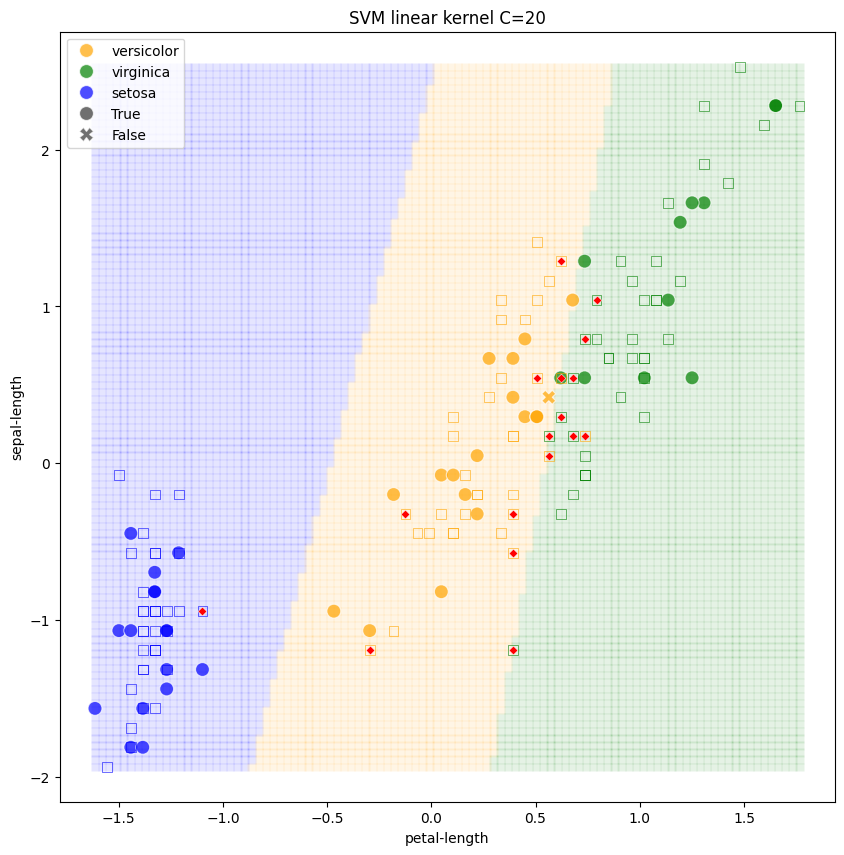

In [69]:
fig, ax = plt.subplots(figsize=(10, 10))
colordict = {'versicolor':'orange',
             'virginica':'g',
             'setosa':'b'}

# Plot simulate data for prediction boundary
sns.scatterplot(data=X_simu,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_simu,
                palette=colordict,
                marker= 's',
                legend=False,
                alpha=.1,
                ax=ax)

# Plot test set
correct_pred = (y_pred_test==y_test)

sns.scatterplot(data=X_test_sc,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_test,
                palette=colordict,
                style=correct_pred.reset_index(drop=True),
                style_order=[True, False],
                s=100,
                alpha=.7,
                ax=ax)

# Plot train set
sns.scatterplot(data=X_train_sc,
                x='petal-length',
                y='sepal-length',
                marker='s',
                ec=y_train.map(colordict),
                fc='none',
                s=50,
                alpha=.7,
                ax=ax)



# Show support vectors
sns.scatterplot(x=svm_l.support_vectors_[:,0],
                y=svm_l.support_vectors_[:,1],
                color='r',
                marker='D',
                s=20,
                ax=ax)


plt.title("SVM linear kernel C=20")

\
***Visualize model prediction when C=1, C=10, C=50, C=100***

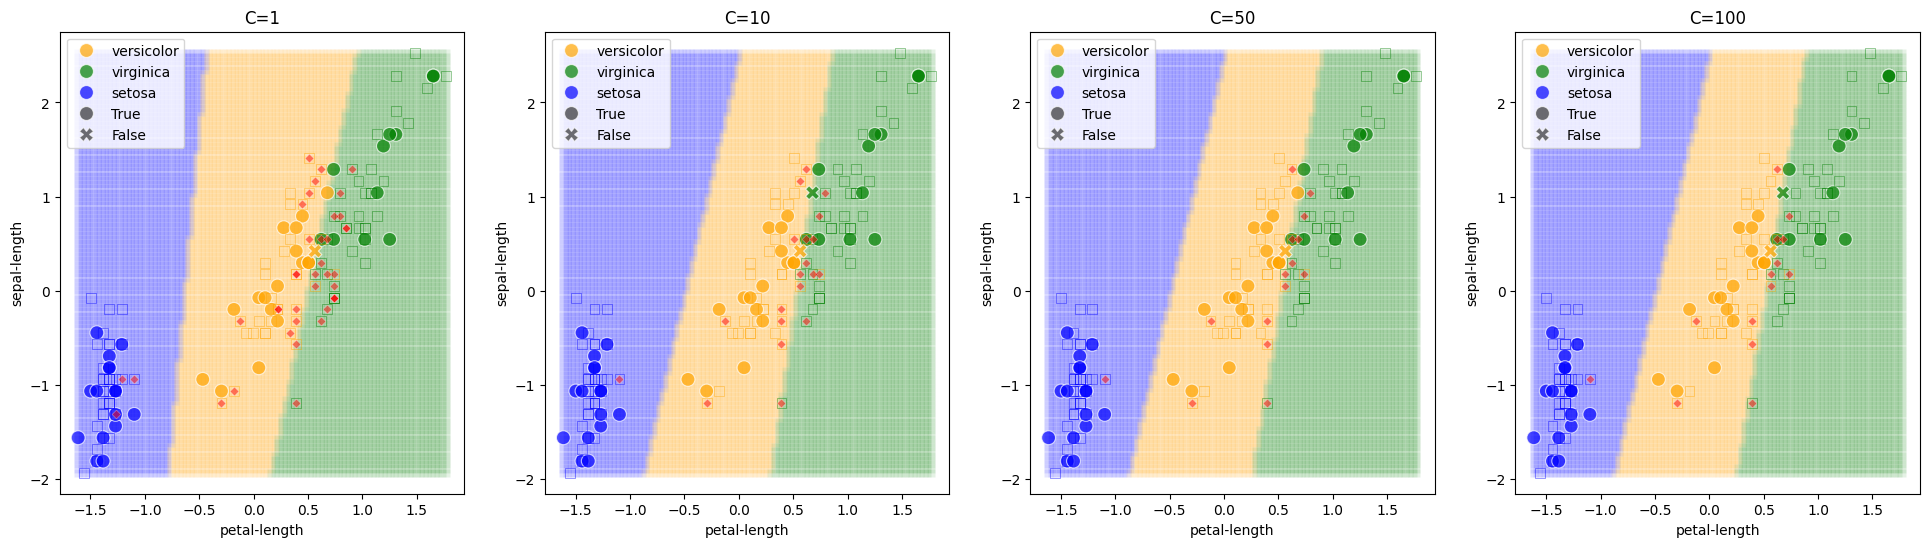

In [70]:
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
colordict = {'versicolor':'orange',
             'virginica':'g',
             'setosa':'b'}

i = 0

for c in [1, 10, 50, 100]:
    # Configure and fit model
    svm_l = svm.SVC(kernel='linear',
                    C=c,
                    probability=True)
    svm_l.fit(X=X_train_sc, y=y_train)

    y_pred_test = svm_l.predict(X_test_sc)
    y_pred_simu = svm_l.predict(X_simu)

    # Plot simulate data for prediction boundary
    sns.scatterplot(data=X_simu,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_simu,
                palette=colordict,
                marker= 's',
                legend=False,
                alpha=.1,
                ax=ax[i])

    # Plot test set
    correct_pred = (y_pred_test==y_test)

    sns.scatterplot(data=X_test_sc,
                    x='petal-length',
                    y='sepal-length',
                    hue=y_pred_test,
                    palette=colordict,
                    style=correct_pred.reset_index(drop=True),
                    style_order=[True, False],
                    s=100,
                    alpha=.7,
                    ax=ax[i])

    # Plot train set
    sns.scatterplot(data=X_train_sc,
                    x='petal-length',
                    y='sepal-length',
                    marker='s',
                    ec=y_train.map(colordict),
                    fc='none',
                    s=50,
                    alpha=.5,
                    ax=ax[i])



    # Show support vectors
    sns.scatterplot(x=svm_l.support_vectors_[:,0],
                    y=svm_l.support_vectors_[:,1],
                    color='r',
                    marker='D',
                    s=20,
                    alpha=.5,
                    ax=ax[i])

    ax[i].title.set_text(f'C={c}')
    i += 1


&nbsp;  
<font color="#275bb0">**Radial basis kernel**</font>

\
Create SVM model using C=1, gamma=0.4 and fit on train data:

In [71]:
svm_rbf = svm.SVC(kernel='rbf',
                  C=1,
                  gamma=0.4,
                  probability=True)
svm_rbf.fit(X=X_train_sc, y=y_train)

SVC(C=1, gamma=0.4, probability=True)

\
Use above SVM model (optimized C) to predict test set (both class and probabilities):

In [72]:
y_pred_test = svm_rbf.predict(X_test_sc)
y_pred_proba = svm_rbf.predict_proba(X_test_sc)

\
Display confusion matrix:

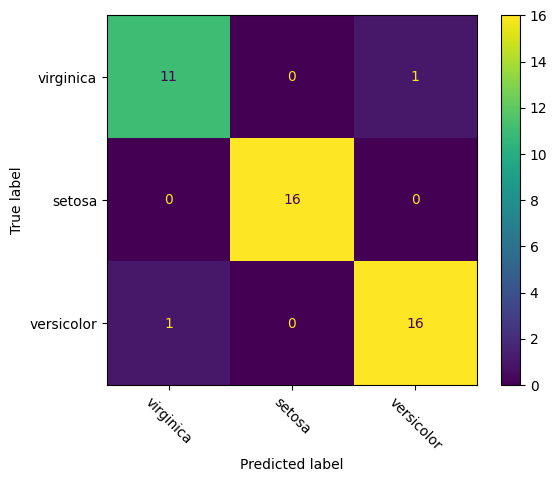

In [73]:
conf_mat = metrics.confusion_matrix(y_test, y_pred_test, labels=['virginica','setosa','versicolor'])
metrics.ConfusionMatrixDisplay(conf_mat,
                               display_labels=['virginica','setosa','versicolor']).plot(xticks_rotation=-45)

\
Evaluate model performance scores based on test set:

In [74]:
acc = metrics.accuracy_score(y_test, y_pred_test)
precision = metrics.precision_score(y_test, y_pred_test, average='weighted')
recall = metrics.recall_score(y_test, y_pred_test, average='weighted')
f1 = metrics.f1_score(y_test, y_pred_test, average='weighted')
matw = metrics.matthews_corrcoef(y_test, y_pred_test)
auc_ovr = metrics.roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')

print(f"Test set performance scores:\n"
      f"accuracy: {acc:.2f}\n"
      f"precision: {precision:.2f}\n"
      f"recall: {recall:.2f}\n"
      f"f1: {f1:.2f}\n"
      f"auc_ovr: {auc_ovr:.2f}\n"
      f"Matthew's corr coef: {matw:.2f}\n"
     )

Test set performance scores:
accuracy: 0.96
precision: 0.96
recall: 0.96
f1: 0.96
auc_ovr: 1.00
Matthew's corr coef: 0.93



\
Perform prediction on a simulated test set:

In [75]:
y_pred_simu = svm_rbf.predict(X_simu)

\
Visualize model prediction:

Text(0.5, 1.0, "'o' for correct prediction, 'x' for incorrect prediction")

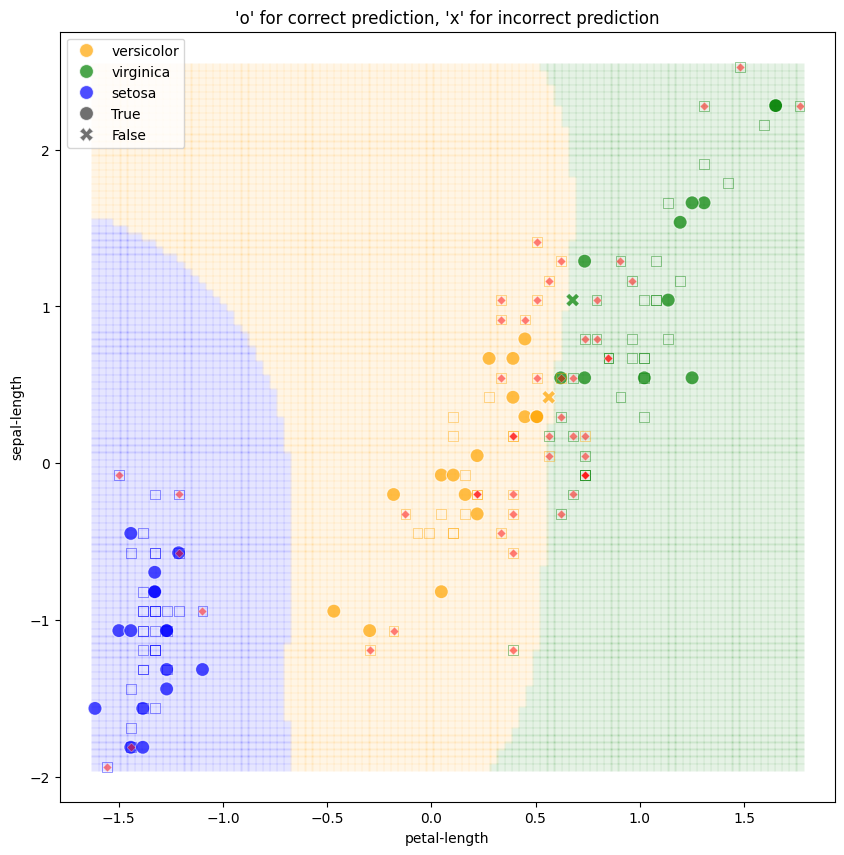

In [76]:
fig, ax = plt.subplots(figsize=(10, 10))
colordict = {'versicolor':'orange',
             'virginica':'g',
             'setosa':'b'}

# Plot simulate data for prediction boundary
sns.scatterplot(data=X_simu,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_simu,
                palette=colordict,
                marker= 's',
                legend=False,
                alpha=.1,
                ax=ax)

# Plot test set
correct_pred = (y_pred_test==y_test)

sns.scatterplot(data=X_test_sc,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_test,
                palette=colordict,
                style=correct_pred.reset_index(drop=True),
                style_order=[True, False],
                s=100,
                alpha=.7,
                ax=ax)

# Plot train set
sns.scatterplot(data=X_train_sc,
                x='petal-length',
                y='sepal-length',
                marker='s',
                ec=y_train.map(colordict),
                fc='none',
                s=50,
                alpha=.5,
                ax=ax)



# Show support vectors
sns.scatterplot(x=svm_rbf.support_vectors_[:,0],
                y=svm_rbf.support_vectors_[:,1],
                color='r',
                marker='D',
                s=20,
                alpha=.5,
                ax=ax)

plt.title("'o' for correct prediction, 'x' for incorrect prediction")

\
***Visualize model prediction when gamma=0.1, 1, 10, 100 (fix C=1)***

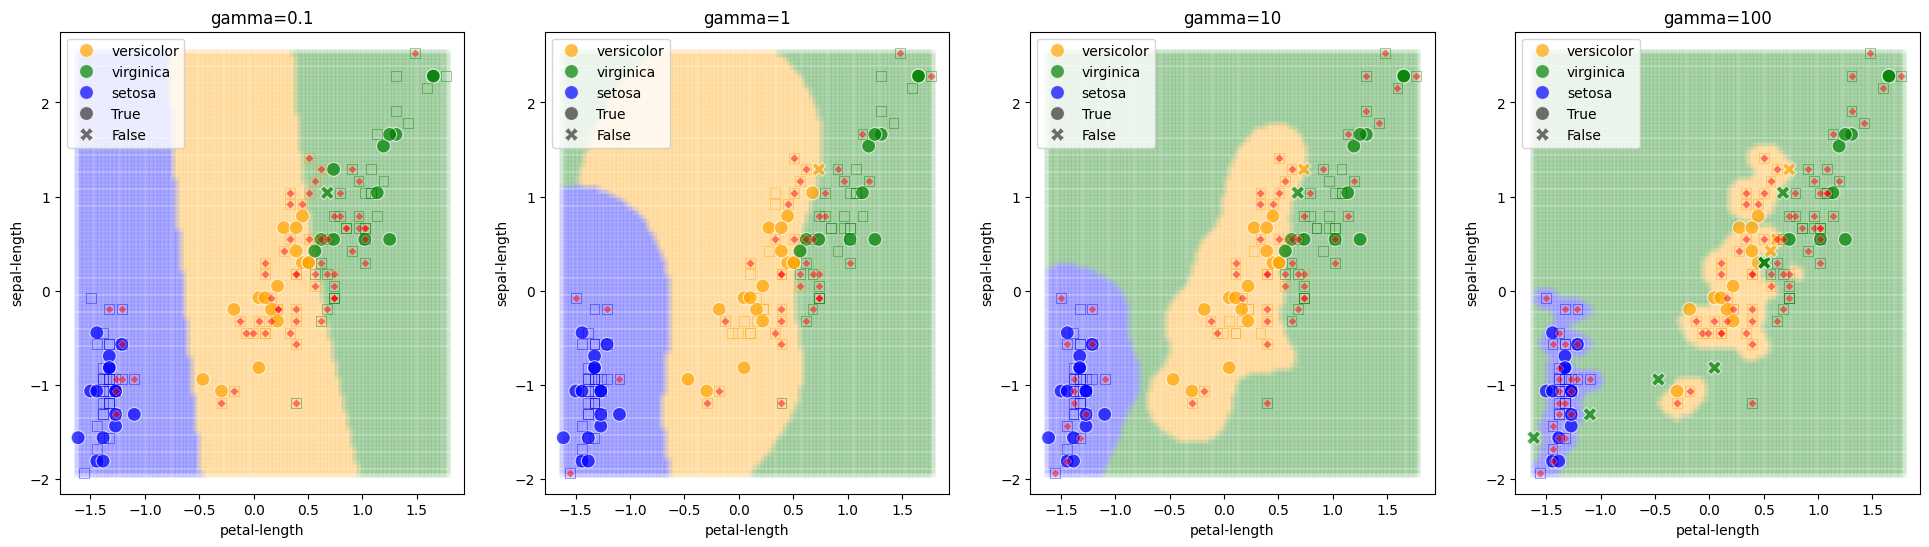

In [77]:
fig, ax = plt.subplots(1, 4, figsize=(24, 6))

colordict = {'versicolor':'orange',
             'virginica':'g',
             'setosa':'b'}

i = 0

for g in [0.1, 1, 10, 100]:

    # Configure and fit model
    svm_rbf = svm.SVC(kernel='rbf',
                  C=1,
                  gamma=g,
                  probability=True)
    svm_rbf.fit(X=X_train_sc, y=y_train)

    y_pred_test = svm_rbf.predict(X_test_sc)
    y_pred_simu = svm_rbf.predict(X_simu)

    # Plot simulate data for prediction boundary
    sns.scatterplot(data=X_simu,
                x='petal-length',
                y='sepal-length',
                hue=y_pred_simu,
                palette={'versicolor':'orange',
                         'virginica':'g',
                         'setosa':'b'},
                marker= 's',
                legend=False,
                alpha=.1,
                ax=ax[i])

    # Plot test set
    correct_pred = (y_pred_test==y_test)

    sns.scatterplot(data=X_test_sc,
                    x='petal-length',
                    y='sepal-length',
                    hue=y_pred_test,
                    palette=["orange", "g", "b"],
                    style=correct_pred.reset_index(drop=True),
                    style_order=[True, False],
                    s=100,
                    alpha=.7,
                    ax=ax[i])

    # Plot train set
    sns.scatterplot(data=X_train_sc,
                    x='petal-length',
                    y='sepal-length',
                    marker='s',
                    ec=y_train.map(colordict),
                    fc='none',
                    s=50,
                    alpha=.5,
                    ax=ax[i])



    # Show support vectors
    sns.scatterplot(x=svm_rbf.support_vectors_[:,0],
                    y=svm_rbf.support_vectors_[:,1],
                    color='r',
                    marker='D',
                    s=20,
                    alpha=.5,
                    ax=ax[i])

    ax[i].title.set_text(f'gamma={g}')
    i += 1
